In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load the dataset
df = pd.read_csv('titanic.csv')

#show first 5 rows
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [34]:
#check for missing values
print(df.isnull().sum())

#fill missing age values w average
df['Age'] = df['Age'].fillna(df['Age'].mean())

#dropping cabins since not enough data
df.drop(columns=['Cabin'], inplace=True)

#fill missing embarked val. w the most common one
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


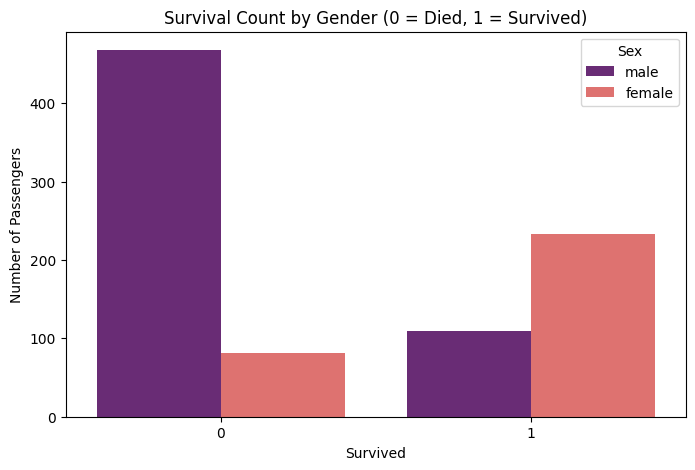

In [35]:
#survival by gender
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', hue='Sex', data=df, palette='magma')
plt.title('Survival Count by Gender (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.show()

/tmp/ipykernel_320/3377057841.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='viridis')


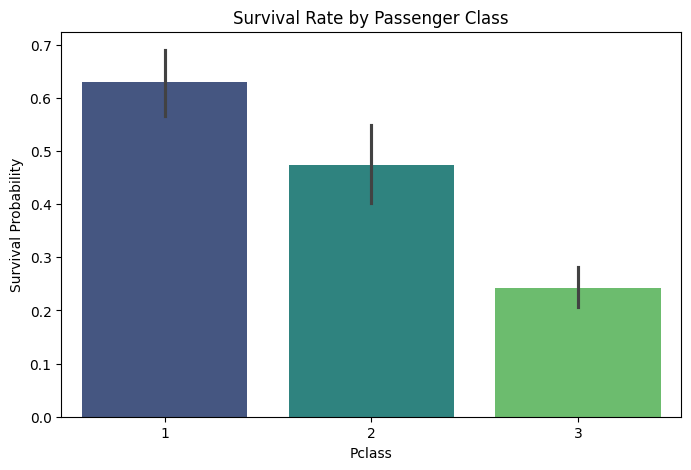

In [36]:
#survival by class
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', data=df, palette='viridis')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Probability')
plt.show()

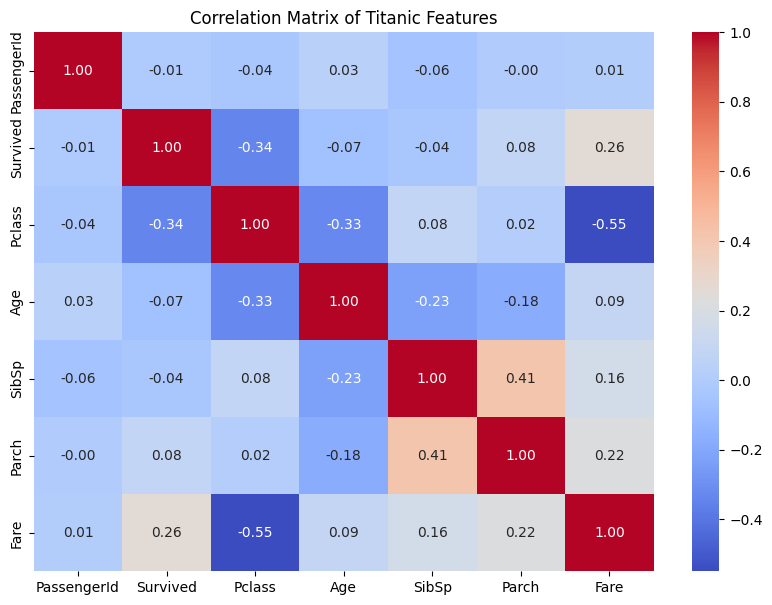

In [37]:
plt.figure(figsize=(10, 7))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Titanic Features')
plt.show()